In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display

RANDOM_STATE = 42
sns.set_theme(style="whitegrid")
plt.rcParams.update({"figure.dpi": 120})

DATA_DIR = Path("../data")
if not DATA_DIR.exists():
    DATA_DIR = Path("Durga/Lab/MLDL/data")

pd.set_option("display.max_columns", 120)

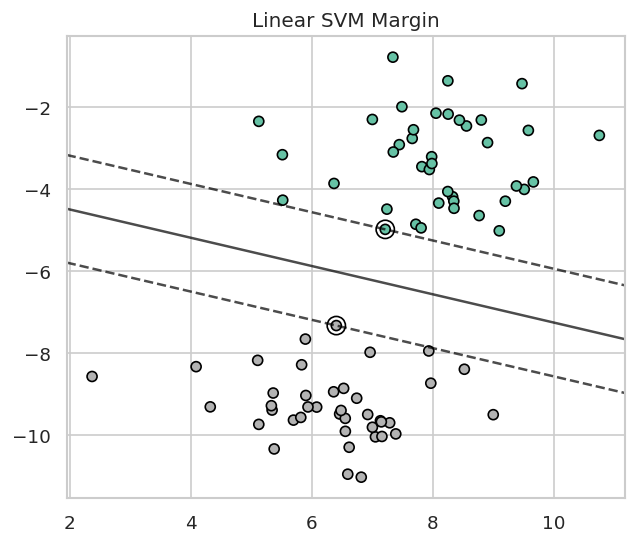

In [2]:
from sklearn.datasets import make_blobs
from sklearn.metrics import ConfusionMatrixDisplay, accuracy_score, classification_report
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

X_blob, y_blob = make_blobs(n_samples=80, centers=2, cluster_std=1.1, random_state=6)
clf = SVC(kernel="linear", C=1000)
clf.fit(X_blob, y_blob)

plt.figure(figsize=(6, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=y_blob, cmap="Set2", edgecolor="black")
ax = plt.gca()
xlim = ax.get_xlim()
ylim = ax.get_ylim()
xx = np.linspace(xlim[0], xlim[1], 80)
yy = np.linspace(ylim[0], ylim[1], 80)
YY, XX = np.meshgrid(yy, xx)
xy = np.vstack([XX.ravel(), YY.ravel()]).T
Z = clf.decision_function(xy).reshape(XX.shape)
ax.contour(XX, YY, Z, colors="black", levels=[-1, 0, 1], alpha=0.7, linestyles=["--", "-", "--"])
ax.scatter(clf.support_vectors_[:, 0], clf.support_vectors_[:, 1], s=120, facecolors="none", edgecolors="black")
plt.title("Linear SVM Margin")
plt.show()

Best parameters: {'svm__C': 10, 'svm__gamma': 'scale', 'svm__kernel': 'rbf'}
Accuracy: 0.965
              precision    recall  f1-score   support

      benign       0.96      0.99      0.97        90
   malignant       0.98      0.92      0.95        53

    accuracy                           0.97       143
   macro avg       0.97      0.96      0.96       143
weighted avg       0.97      0.97      0.96       143



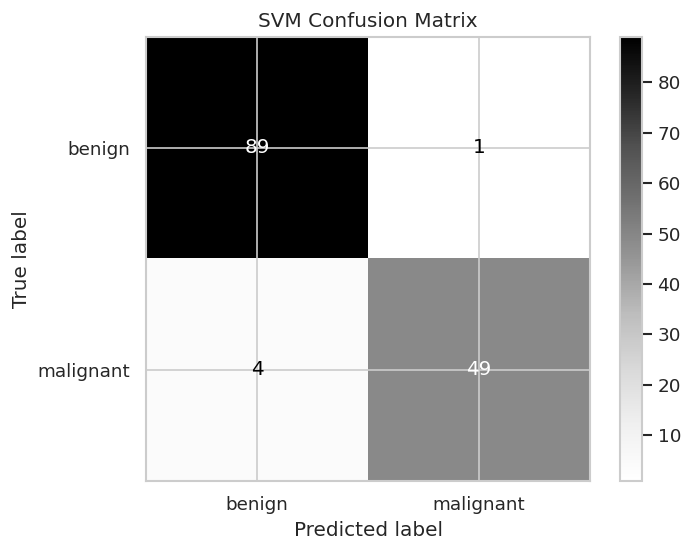

In [3]:
df = pd.read_csv(DATA_DIR / "breast_cancer_logistic.csv")
df = df.drop(columns=[c for c in df.columns if c.lower().startswith("unnamed")])
X = df.drop(columns=["id", "diagnosis"])
y = LabelEncoder().fit_transform(df["diagnosis"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

pipe = Pipeline(
    steps=[
        ("scale", StandardScaler()),
        ("svm", SVC(probability=True, random_state=RANDOM_STATE)),
    ]
)
search = GridSearchCV(
    pipe,
    param_grid={
        "svm__kernel": ["linear", "rbf"],
        "svm__C": [0.1, 1, 10],
        "svm__gamma": ["scale", 0.01],
    },
    scoring="f1",
    cv=5,
    n_jobs=-1,
)
search.fit(X_train, y_train)
pred = search.predict(X_test)

print("Best parameters:", search.best_params_)
print(f"Accuracy: {accuracy_score(y_test, pred):.3f}")
print(classification_report(y_test, pred, target_names=["benign", "malignant"]))
ConfusionMatrixDisplay.from_predictions(y_test, pred, display_labels=["benign", "malignant"], cmap="Greys")
plt.title("SVM Confusion Matrix")
plt.show()